## 1. Setup: Reload Pipeline Functions and Build Holdings

Reload the Chapter 04/05 helper functions (self-contained copy, per this project's per-notebook convention), select both the plain Top-N and industry-neutral portfolios for the final chosen N, and construct `hold_ret` — the point-in-time-safe forward return used throughout this chapter's risk analysis.

In [1]:
import sys
sys.path.append(r"D:\Quant\Multi_factor_project")
from config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

factor_panel = pd.read_parquet(f"{DATA_CLEAN}/factor_panel.parquet")
universe_raw = pd.read_parquet(f"{DATA_RAW}/industry/hs300_monthly_universe.parquet")

# 1. Paste in the definition of select_top_n
def select_top_n(factor_panel, score_col='composite', top_n=30):
    \"\"\"
    Rank stocks by composite factor score each month and select the Top N.
    \"\"\"
    df = factor_panel.dropna(subset=[score_col]).copy()
    df['rank'] = df.groupby('month')[score_col].rank(ascending=False)
    selected = df[df['rank'] <= top_n].copy()
    print(f"Stock selection complete, Top{top_n}")
    print(f"Average number of stocks selected per month: {selected.groupby('month').size().mean():.1f}")
    
    return selected
# 2. Paste in the definition of calc_portfolio_return
def calc_portfolio_return(selected_stocks):
    \"\"\"
    Equal-weight the Top N holdings and return the portfolio's gross monthly return
    (indexed by the stock-selection month T).
    Includes the Bug1 fix: for a stock that drops out of and re-enters the universe,
    the next row is not necessarily the following calendar month -> the return is voided.
    \"\"\"
    df = factor_panel.copy()
    df = df.sort_values(['ts_code','month'])
    df['next_ret']   = df.groupby('ts_code')['ret_1m'].shift(-1)
    df['next_month'] = df.groupby('ts_code')['month'].shift(-1)

    gap = (df['next_month'].dt.to_period('M') - df['month'].dt.to_period('M')
           ).apply(lambda x: x.n if pd.notna(x) else np.nan)
    df.loc[gap != 1, 'next_ret'] = np.nan

    # Safeguard: drop any leftover same-named columns from `selected`, to avoid merge suffix collisions (_x/_y)
    clean_sel = selected_stocks.drop(
        columns=[c for c in ['next_ret','next_month'] if c in selected_stocks.columns])
    merged = clean_sel.merge(df[['ts_code','month','next_ret']],
                             on=['ts_code','month'], how='left')

    portfolio_ret = merged.groupby('month')['next_ret'].mean().dropna()
    return portfolio_ret
# 3. Paste in the definition of calc_net_return (the same block you pasted earlier)
def calc_net_return(selected_stocks, cost=0.0025):
    \"\"\"Gross return minus turnover cost. Returns: (net return series, average monthly turnover)\"\"\"
    holdings = selected_stocks.groupby('month')['ts_code'].apply(set)
    months = sorted(holdings.index)
    turnover = pd.Series({
        cur: len(holdings[cur] - holdings[prev]) / len(holdings[cur])
        for prev, cur in zip(months[:-1], months[1:])
    })
    gross = calc_portfolio_return(selected_stocks)
    net = gross - (turnover * cost).reindex(gross.index).fillna(0)
    avg_turnover = turnover.reindex(gross.index).mean()
    return net, avg_turnover
# 4. Paste in the definition of build_industry_neutral
def build_industry_neutral(factor_panel, universe_raw, top_n):
    \"\"\"Allocate the stock-selection count per industry according to that industry's
    CSI 300 market-cap weight, rank by composite within each industry, and hold the
    overall portfolio equal-weighted.\"\"\"
    uni = universe_raw[['month','con_code','weight']].copy()
    uni['month'] = pd.to_datetime(uni['month'].astype(str))
    ind_map = factor_panel[['month','ts_code','industry_name']].drop_duplicates()
    uni = uni.merge(ind_map, left_on=['month','con_code'],
                    right_on=['month','ts_code'], how='left').drop(columns='ts_code')

    ind_w = uni.groupby(['month','industry_name'])['weight'].sum().reset_index()
    ind_w['ind_weight'] = ind_w['weight'] / ind_w.groupby('month')['weight'].transform('sum')

    df = factor_panel.dropna(subset=['composite','industry_name']).copy()
    df = df.merge(ind_w[['month','industry_name','ind_weight']],
                  on=['month','industry_name'], how='left')
    df['n_pick'] = (df['ind_weight'] * top_n).round().astype(int)
    df['ind_rank'] = df.groupby(['month','industry_name'])['composite'].rank(ascending=False)
    picked = df[(df['n_pick']>0) & (df['ind_rank'] <= df['n_pick'])].copy()

    print(f"Average monthly holdings: {picked.groupby('month').size().mean():.0f} (target ~= {top_n})")
    return picked
    
BEST_N = 50   # <- set this to the N you finalized in Chapter 05 (the industry-neutral scheme selected 50)
picked_plain   = select_top_n(factor_panel, score_col='composite', top_n=BEST_N)
picked_neutral = build_industry_neutral(factor_panel, universe_raw, BEST_N)

def add_holding_return(factor_panel):
    fp = factor_panel.sort_values(['ts_code','month']).copy()
    fp['hold_ret'] = fp.groupby('ts_code')['ret_1m'].shift(-1)
    fp['next_month'] = fp.groupby('ts_code')['month'].shift(-1)
    gap = (fp['next_month'].dt.to_period('M') - fp['month'].dt.to_period('M')).apply(
        lambda x: x.n if pd.notna(x) else np.nan)
    fp.loc[gap != 1, 'hold_ret'] = np.nan   # stock drops out and re-enters -> return voided (same as Bug1)
    return fp

fp_hold = add_holding_return(factor_panel)

选股完成，Top50
每月平均选中股票数：50.0
月均持仓：50 只（目标≈50）


## 2. Benchmark Industry Weights and Returns

Reconstruct the CSI 300 benchmark's industry weights and market-cap-weighted industry returns from constituent-level data, with an internal check that weights sum to 1 each month.

In [14]:
def build_benchmark_industry(fp_hold, universe_raw):
    uni = universe_raw[['month','con_code','weight']].copy()
    uni['month'] = pd.to_datetime(uni['month'].astype(str))
    fp = fp_hold[['month','ts_code','industry_name','hold_ret']]
    uni = uni.merge(fp, left_on=['month','con_code'],
                    right_on=['month','ts_code'], how='inner').drop(columns='ts_code')

    # Industry weight: sum constituent weights, then normalize per month
    uni['w_norm'] = uni['weight'] / uni.groupby('month')['weight'].transform('sum')
    w_b = uni.groupby(['month','industry_name'])['w_norm'].sum().rename('w_b')

    # Industry return: market-cap weighted within each industry
    uni['w_in_ind'] = uni['weight'] / uni.groupby(['month','industry_name'])['weight'].transform('sum')
    uni['wr'] = uni['w_in_ind'] * uni['hold_ret']
    r_b = uni.groupby(['month','industry_name'])['wr'].sum().rename('r_b')

    out = pd.concat([w_b, r_b], axis=1).reset_index()
    chk = out.groupby('month')['w_b'].sum()
    assert (chk - 1).abs().max() < 1e-6, "Benchmark industry weights do not sum to 1 - check the data"
    return out

## 3. Portfolio Industry Weights and Returns

Compute the equal-weighted portfolio's industry weights (by holding count) and industry-level average returns, for use in Brinson attribution.

In [19]:
def build_portfolio_industry(picked, fp_hold):
    p = picked[['month','ts_code']].merge(
        fp_hold[['month','ts_code','industry_name','hold_ret']],
        on=['month','ts_code'], how='left').dropna(subset=['hold_ret'])

    cnt = p.groupby(['month','industry_name'])['ts_code'].count()
    w_p = (cnt / p.groupby('month')['ts_code'].count()).rename('w_p')
    r_p = p.groupby(['month','industry_name'])['hold_ret'].mean().rename('r_p')
    return pd.concat([w_p, r_p], axis=1).reset_index()

## 4. Brinson-Fachler Performance Attribution

Decompose excess return into allocation, selection, and interaction effects, with two validation checks: the BF identity (excess = sum of three effects) and a cross-chapter consistency check against Chapter 05's gross portfolio return.

In [20]:
def brinson_attribution(picked, fp_hold, universe_raw):
    pb = build_portfolio_industry(picked,fp_hold)
    bb = build_benchmark_industry(fp_hold, universe_raw)

    # Total monthly benchmark return (computed first, needed later to fill missing industries)
    bb['wbr'] = bb['w_b'] * bb['r_b']
    rb_tot = bb.groupby('month')['wbr'].sum()
    bb = bb.drop(columns='wbr')

    m = bb.merge(pb, on=['month','industry_name'], how='outer')
    m[['w_b','w_p']] = m[['w_b','w_p']].fillna(0)
    m['r_b_tot'] = m['month'].map(rb_tot)
    m['r_b'] = m['r_b'].fillna(m['r_b_tot'])   # industries missing from the benchmark are treated as the market average (very rare)
    m['r_p'] = m['r_p'].fillna(m['r_b'])       # industries not held: no selection effect, the entire underweight impact falls into allocation

    # ---- BHB/BF three-effect decomposition ----
    m['allocation_effect'] = (m['w_p'] - m['w_b']) * (m['r_b'] - m['r_b_tot'])   # Brinson-Fachler convention
    m['selection_effect']  = m['w_b'] * (m['r_p'] - m['r_b'])
    m['interaction_effect'] = (m['w_p'] - m['w_b']) * (m['r_p'] - m['r_b'])

    monthly = m.groupby('month')[['allocation_effect','selection_effect','interaction_effect']].sum()
    monthly['benchmark_return'] = rb_tot
    monthly['portfolio_return'] = (m['w_p'] * m['r_p']).groupby(m['month']).sum()
    monthly['excess_return'] = monthly['portfolio_return'] - monthly['benchmark_return']
    monthly['sum_of_three_effects'] = monthly[['allocation_effect','selection_effect','interaction_effect']].sum(axis=1)

    err = (monthly['excess_return'] - monthly['sum_of_three_effects']).abs().max()
    print(f"OK Identity check: max |excess - sum of three effects| = {err:.2e} (should be < 1e-10)")
    return m, monthly

m_plain,  mon_plain  = brinson_attribution(picked_plain, fp_hold, universe_raw)
m_neutral, mon_neutral = brinson_attribution(picked_neutral, fp_hold, universe_raw)

# Consistency cross-check (mandatory): the Brinson portfolio return must equal Chapter 05's gross return
gross_05 = calc_portfolio_return(picked_plain)
diff = (mon_plain['portfolio_return'] - gross_05.reindex(mon_plain.index)).abs().max()
print(f"OK Consistency check: max |Brinson portfolio return - Ch.05 gross return| = {diff:.2e} (should be < 1e-10)")
print(f"  Brinson mean monthly portfolio return {mon_plain['portfolio_return'].mean()*100:.2f}% | Ch.05 mean monthly gross return {gross_05.mean()*100:.2f}%")

✓ 恒等式检验：|超额 − 三效应合计| 最大误差 = 1.99e-17（应 < 1e-10）
✓ 恒等式检验：|超额 − 三效应合计| 最大误差 = 3.30e-17（应 < 1e-10）
✓ 口径旁证：|Brinson组合收益 − 05毛收益| 最大误差 = 2.78e-17（应 < 1e-10）
  Brinson月均组合收益 0.78% ｜ 05毛收益月均 0.78%


## 5. Attribution Summary and Visualization

Summarize cumulative and annualized attribution effects for both the plain and industry-neutral portfolios, and visualize per-industry contributions.

===== 纯排名Top50 =====
      累计(算术)    折合年化
配置效应 -0.0052 -0.0005
选择效应  0.2698  0.0272
交互效应  0.0725  0.0073
超额收益  0.3372  0.0340
结构占比：配置 -2% ｜ 选择 80% ｜ 交互 22%



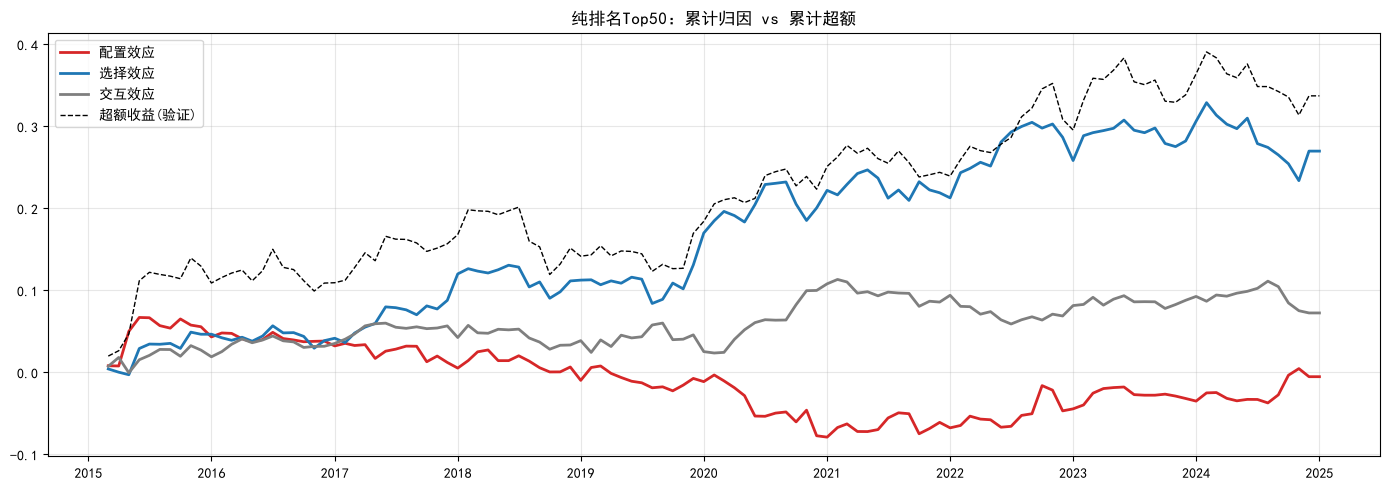

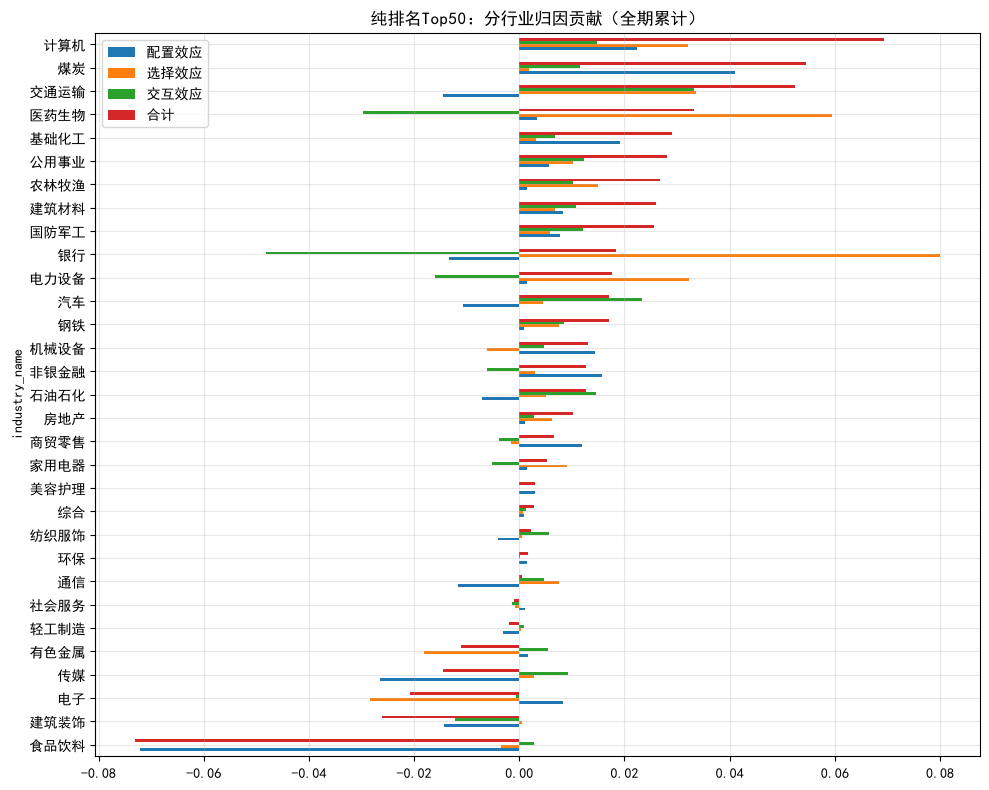

===== 行业中性Top50 =====
      累计(算术)    折合年化
配置效应  0.0306  0.0031
选择效应  0.2537  0.0256
交互效应  0.0211  0.0021
超额收益  0.3055  0.0308
结构占比：配置 10% ｜ 选择 83% ｜ 交互 7%



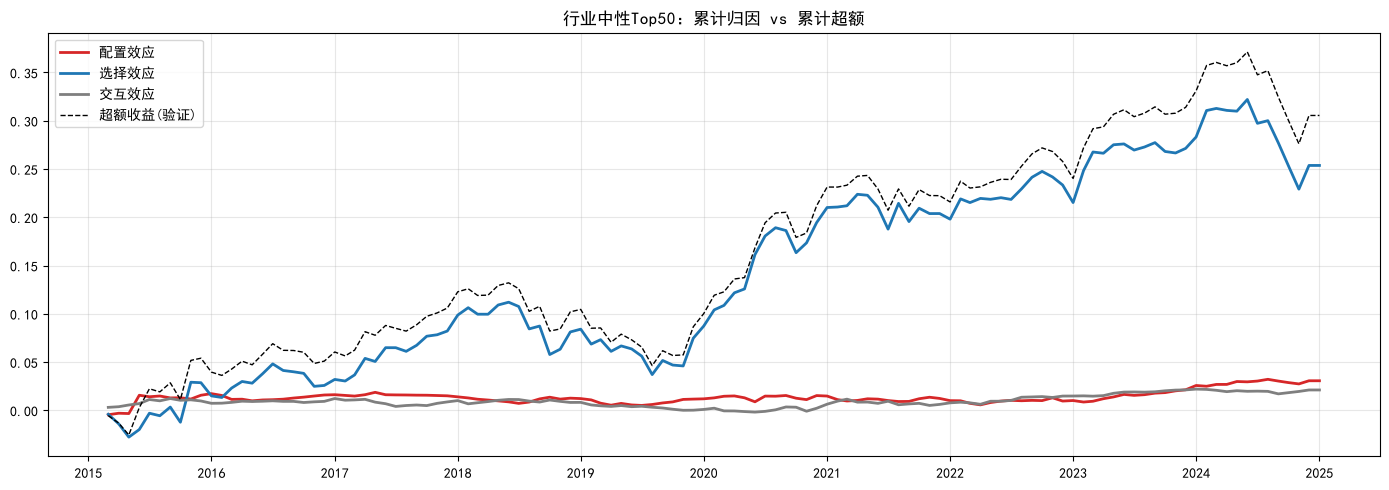

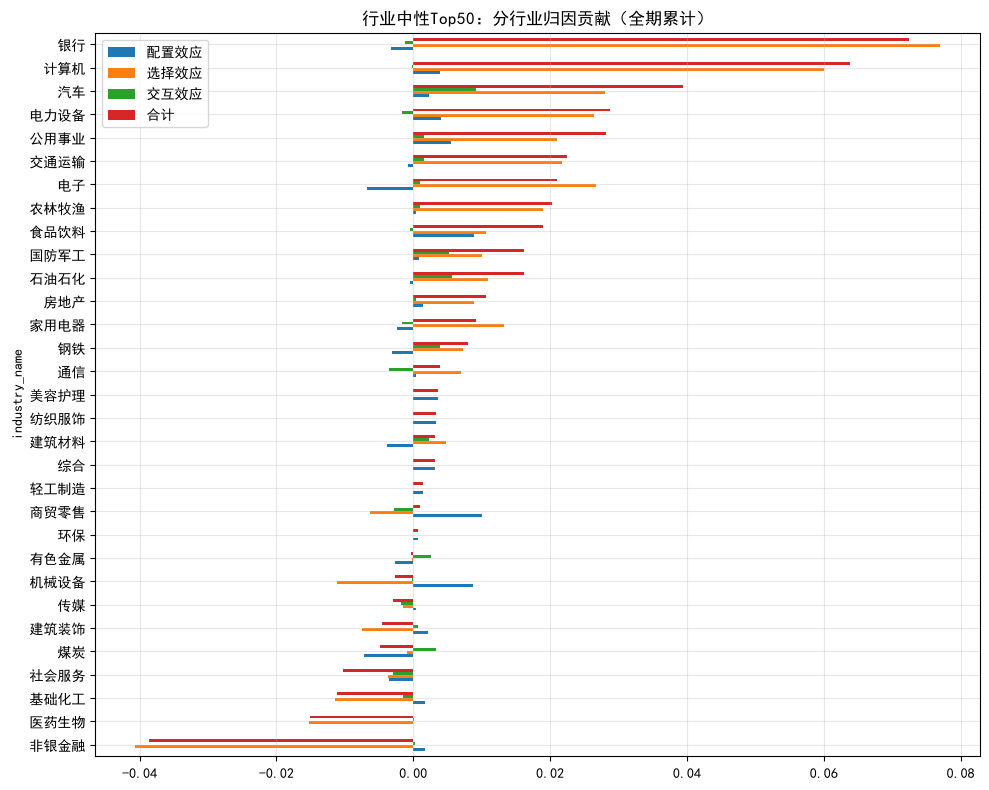

In [22]:
def summarize_brinson(m, monthly, name):
    tot = monthly[['allocation_effect','selection_effect','interaction_effect','excess_return']].sum()
    ann = tot / len(monthly) * 12
    print(f"===== {name} =====")
    print(pd.DataFrame({'cumulative_(arithmetic)': tot, 'annualized_equivalent': ann},
          index=['allocation_effect','selection_effect','interaction_effect','excess_return']).round(4))
    print(f"Structural share: allocation {tot['allocation_effect']/tot['excess_return']*100:.0f}% | "
          f"selection {tot['selection_effect']/tot['excess_return']*100:.0f}% | "
          f"interaction {tot['interaction_effect']/tot['excess_return']*100:.0f}%\n")

    # Cumulative curves: three effects + excess-return validation line (should overlap exactly)
    fig, ax = plt.subplots(figsize=(14, 5))
    idx = monthly.index + pd.offsets.MonthBegin(1)   # same offset convention as Chapter 05
    for col, c in zip(['allocation_effect','selection_effect','interaction_effect'], ['#d62728','#1f77b4','#7f7f7f']):
        ax.plot(idx, monthly[col].cumsum(), label=col, linewidth=2, color=c)
    ax.plot(idx, monthly['excess_return'].cumsum(), label='excess return (validation)', 
            linewidth=1, color='black', linestyle='--')
    ax.legend(); ax.grid(alpha=0.3); ax.set_title(f'{name}: Cumulative Attribution vs. Cumulative Excess Return')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/plots/brinson_cum_{name}.png", dpi=150)
    plt.show()

    # Per-industry contribution (summed over the full period)
    by_ind = m.groupby('industry_name')[['allocation_effect','selection_effect','interaction_effect']].sum()
    by_ind['total'] = by_ind.sum(axis=1)
    by_ind = by_ind.sort_values('total')
    by_ind.plot.barh(figsize=(10, 8), stacked=False)
    plt.title(f'{name}: Attribution Contribution by Industry (Full-Period Cumulative)'); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/plots/brinson_industry_{name}.png", dpi=150)
    plt.show()
    return by_ind

ind_plain   = summarize_brinson(m_plain,   mon_plain,   f'PureRankTop{BEST_N}')
ind_neutral = summarize_brinson(m_neutral, mon_neutral, f'IndustryNeutralTop{BEST_N}')

## 6. Drawdown-Window Attribution

Identify the period of worst portfolio-vs-benchmark relative drawdown and decompose which effects, and which industries, drove it — a stress-period diagnostic beyond the standard full-sample summary.

===== 纯排名Top50 =====
相对回撤区间：2018-06 → 2018-09，相对最大回撤 -8.5%
      窗口内累计   占超额比
配置效应 -0.020  0.240
选择效应 -0.038  0.462
交互效应 -0.024  0.298
窗口内累计超额：-8.2%



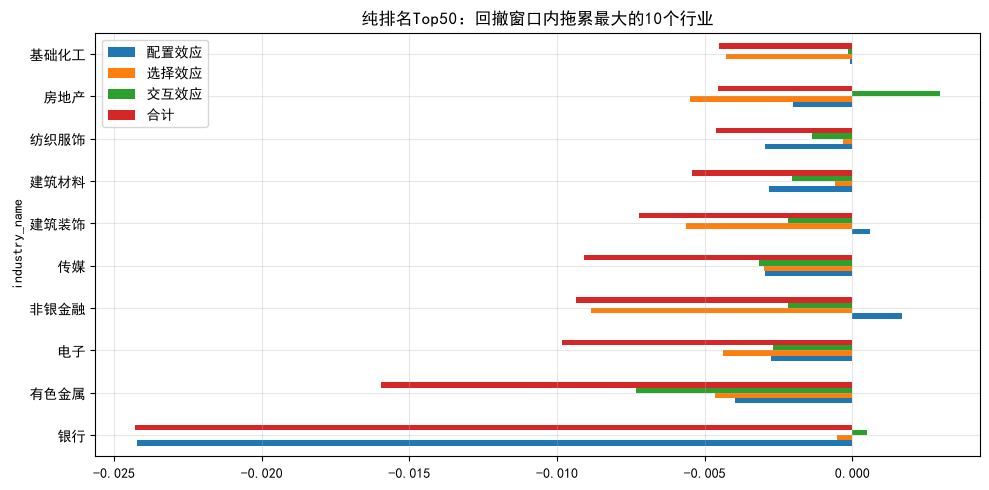

===== 行业中性Top50 =====
相对回撤区间：2024-05 → 2024-10，相对最大回撤 -8.8%
      窗口内累计   占超额比
配置效应 -0.002  0.023
选择效应 -0.093  0.976
交互效应 -0.000  0.002
窗口内累计超额：-9.5%



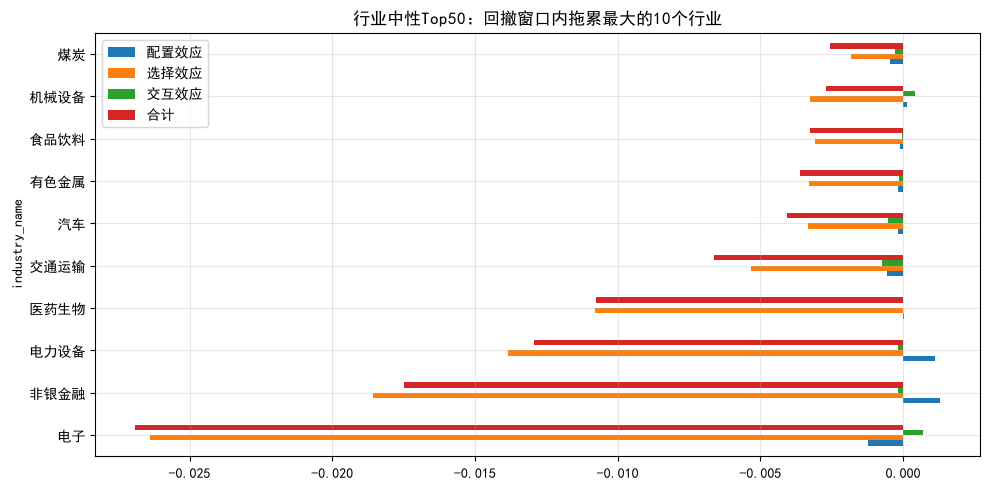

In [21]:
def worst_rel_drawdown(monthly):
    rel_nav = (1+monthly['portfolio_return']).cumprod() / (1+monthly['benchmark_return']).cumprod()
    dd = rel_nav / rel_nav.cummax() - 1
    trough = dd.idxmin()
    peak = rel_nav.loc[:trough].idxmax()
    return peak, trough, dd.min()

def attribute_window(m, monthly, name):
    peak, trough, mdd = worst_rel_drawdown(monthly)
    print(f"===== {name} =====")
    print(f"Relative drawdown window: {peak:%Y-%m} -> {trough:%Y-%m}, max relative drawdown {mdd*100:.1f}%")

    win_m  = m[(m['month'] > peak) & (m['month'] <= trough)]
    win_ex = monthly.loc[(monthly.index > peak) & (monthly.index <= trough), 'excess_return'].sum()
    eff = win_m[['allocation_effect','selection_effect','interaction_effect']].sum()
    print(pd.DataFrame({'cumulative_in_window': eff, 'share_of_excess': eff/win_ex}).round(3))
    print(f"Cumulative excess return within the window: {win_ex*100:.1f}%\n")

    by_ind = win_m.groupby('industry_name')[['allocation_effect','selection_effect','interaction_effect']].sum()
    by_ind['total'] = by_ind.sum(axis=1)
    by_ind.sort_values('total').head(10).plot.barh(figsize=(10, 5))
    plt.title(f'{name}: 10 Most Damaging Industries During the Drawdown Window'); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/plots/brinson_drawdown_{name}.png", dpi=150)
    plt.show()

attribute_window(m_plain,   mon_plain,   f'PureRankTop{BEST_N}')
attribute_window(m_neutral, mon_neutral, f'IndustryNeutralTop{BEST_N}')

## 7. Benchmark Reconstruction Validation ("Dividend Signature" Check)

Compare the reconstructed benchmark (built from total-return stock series) against the official CSI 300 price index. A steady, non-random upward drift in the difference is consistent with the official index excluding dividends, and serves as a sanity check on the underlying data.

基准月度收益计算完成：119个月
月均差：0.23% ｜ 折合年化：2.8%


<Axes: title={'center': '重构基准 ÷ 官方指数 累计差（稳定爬升 = 股息特征）'}, xlabel='month'>

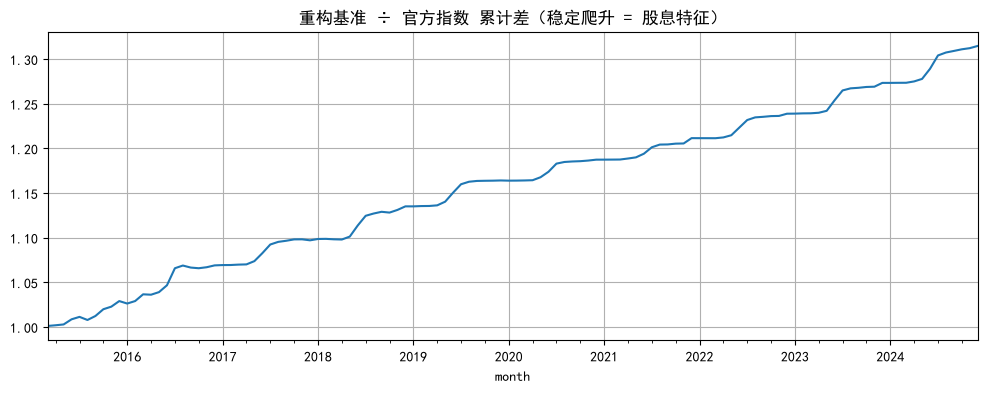

In [25]:
# Validation: check whether the gap between the reconstructed benchmark and the official
# index shows a "dividend signature" (a steady upward drift, since the reconstructed
# benchmark is built from total-return stock series while the official index is price-only)
recon = mon_plain['benchmark_return'].copy()
recon.index = recon.index + pd.offsets.MonthBegin(1)   # same offset as Chapter 05, to align with the official index's month

hs300 = pd.read_parquet(f"{DATA_RAW}/daily/hs300_index.parquet")
def calc_benchmark_return(hs300):
    \"\"\"CSI 300 monthly return\"\"\"
    df = hs300.copy()
    df['month'] = df['trade_date'].dt.to_period('M').dt.to_timestamp()
    
    monthly_close = df.groupby('month')['close'].last()
    benchmark_ret = monthly_close.pct_change().dropna()
    
    print(f"Benchmark monthly return calculation complete: {len(benchmark_ret)} months")
    return benchmark_ret

benchmark_ret = calc_benchmark_return(hs300)

cmp_bench = pd.DataFrame({'reconstructed_benchmark': recon, 'official_index': benchmark_ret}).dropna()
cmp_bench['diff'] = cmp_bench['reconstructed_benchmark'] - cmp_bench['official_index']

print(f"Mean monthly difference: {cmp_bench['diff'].mean()*100:.2f}% | annualized equivalent: {cmp_bench['diff'].mean()*12*100:.1f}%")
(1+cmp_bench['diff']).cumprod().plot(figsize=(12,4), grid=True,
    title='Reconstructed Benchmark / Official Index: Cumulative Difference (steady drift up = dividend signature)')

## 8. Factor IC Across Drawdown Windows

Compare each component factor's Rank IC during the 2018 and 2024 drawdown windows against its full-period IC, to see whether factor efficacy broke down during stress periods.

**Please double-check the `factors` list below** — see review notes beneath the notebook.

['mom_12m_std', 'mom_1m_std', 'roe_ttm_std', 'net_margin_std', 'pe_ttm_std', 'pb_std', 'value_std']
                2018回撤  2024回撤  全期IC(基准)
mom_12m_std     -0.044  -0.138     0.040
net_margin_std  -0.084   0.005     0.005
value_std        0.062  -0.012     0.041
composite       -0.064  -0.115     0.053


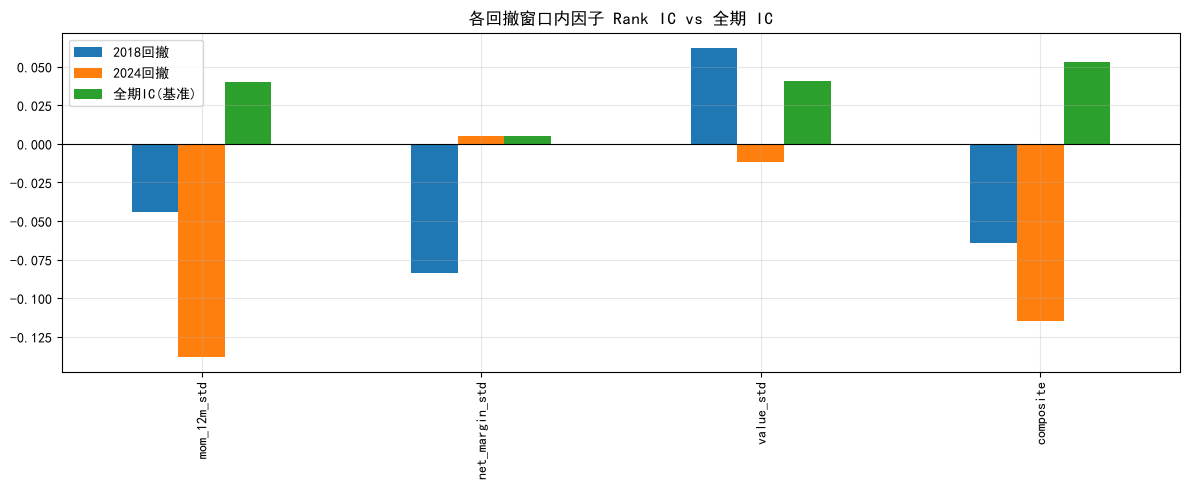

In [27]:
# 1) First check which standardized factor columns actually exist in the panel
print([c for c in fp_hold.columns if c.endswith('_std')])

# 2) Keep only the factors that actually went into `composite` <- update this list to match your Chapter 03 composition
factors = ['mom_12m_std', 'net_margin_std', 'value_std']  # <- placeholder, replace with your actual components

def factor_ic_by_window(fp_hold, factors, windows):
    def monthly_ic(df, f):
        v = df[[f, 'hold_ret']].dropna()
        return v[f].corr(v['hold_ret'], method='spearman') if len(v) >= 10 else np.nan

    cols = factors + ['composite']   # composite serves as the overall reference
    full = {f: fp_hold.groupby('month').apply(
        lambda g: monthly_ic(g, f), include_groups=False).mean() for f in cols}

    rows = {}
    for name, (s, e) in windows.items():
        win = fp_hold[(fp_hold['month'] > s) & (fp_hold['month'] <= e)]
        rows[name] = {f: win.groupby('month').apply(
            lambda g: monthly_ic(g, f), include_groups=False).mean() for f in cols}

    out = pd.DataFrame(rows)
    out['full_period_ic_(baseline)'] = pd.Series(full)
    return out.round(3)

windows = {
    '2018_drawdown': (pd.Timestamp('2018-06'), pd.Timestamp('2018-09')),
    '2024_drawdown': (pd.Timestamp('2024-05'), pd.Timestamp('2024-10')),
}
ic_cmp = factor_ic_by_window(fp_hold, factors, windows)
print(ic_cmp)

ic_cmp.plot.bar(figsize=(12, 5))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Factor Rank IC by Drawdown Window vs. Full-Period IC'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Momentum Factor IC: Breakdown and Recovery

Track the rolling 3-month IC of the momentum factor through the drawdown windows and quantify how long it took to recover to its full-period average afterward.

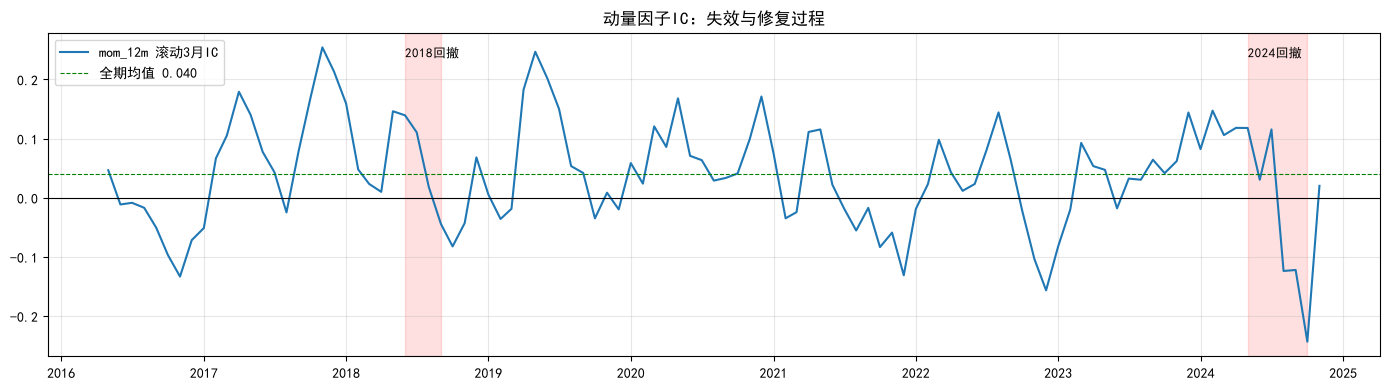

2018回撤（2018-09结束）：之后连续负IC 1 个月；IC回到全期均值以上用了 2 个月
2024回撤（2024-10结束）：之后连续负IC 0 个月；IC回到全期均值以上用了 1 个月


In [28]:
def factor_ic_series(fp_hold, factor):
    def monthly_ic(g):
        v = g[[factor,'hold_ret']].dropna()
        return v[factor].corr(v['hold_ret'], method='spearman') if len(v)>=10 else np.nan
    return fp_hold.groupby('month').apply(monthly_ic, include_groups=False)

ic_mom = factor_ic_series(fp_hold, 'mom_12m_std')
ic_mean = ic_mom.mean()

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(ic_mom.index, ic_mom.rolling(3).mean(), lw=1.5, label='mom_12m 3-month rolling IC')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(ic_mean, color='green', ls='--', lw=0.8, label=f'full-period mean {ic_mean:.3f}')
for name,(s,e) in windows.items():
    ax.axvspan(s, e, color='red', alpha=0.12)
    ax.text(s, ax.get_ylim()[1]*0.85, name, fontsize=9)
ax.legend(); ax.grid(alpha=0.3); ax.set_title('Momentum Factor IC: Breakdown and Recovery')
plt.tight_layout(); plt.show()

def recovery_stats(ic_series, end, full_mean):
    after = ic_series[ic_series.index > end].dropna()
    n_neg = sum(1 for v in after if v < 0) if (after < 0).all() else \
            next((i for i, v in enumerate(after) if v >= 0), len(after))
    above = after[after >= full_mean]
    n_mean = (above.index[0].to_period('M') - end.to_period('M')).n if len(above) else None
    return n_neg, n_mean

for name,(s,e) in windows.items():
    n_neg, n_mean = recovery_stats(ic_mom, e, ic_mean)
    print(f"{name} (ended {e:%Y-%m}): {n_neg} consecutive months of negative IC afterward; took {n_mean} months for IC to recover above the full-period mean")

## 10. Volatility-Targeting Overlay

Scale portfolio exposure inversely to trailing realized volatility (using only information available at the end of the prior month, to avoid look-ahead), capped at full investment with no leverage, and charge transaction costs on position-size changes.

In [3]:
# ========== Volatility targeting (position-sizing overlay) ==========
def apply_vol_target(p_ret, target_vol=0.15, lookback=6, cost=0.0025):
    \"\"\"
    Estimate realized volatility as of the end of the prior month -> set this month's
    position size: w = target_vol / realized_vol
    Capped at 1 (no leverage); uninvested cash earns zero return; position changes
    (|delta_w|) incur two-way transaction cost.
    \"\"\"
    rv = p_ret.rolling(lookback).std() * np.sqrt(12)      # annualized realized volatility
    w = (target_vol / rv).clip(upper=1.0).shift(1)        # shift(1): use last month's info to set this month's position, avoiding look-ahead
    overlay_cost = w.diff().abs().fillna(0) * cost        # rescaling the position itself also incurs trading cost
    r_adj = (p_ret * w - overlay_cost).dropna()
    return r_adj, w.dropna()

def perf_stats(p, b):
    common = p.index.intersection(b.index)
    p, b = p.loc[common], b.loc[common]
    ann_ret = (1+p).prod()**(12/len(p)) - 1
    ann_vol = p.std() * np.sqrt(12)
    ex = p - b
    nav = (1+p).cumprod()
    return pd.Series({'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': ann_ret/ann_vol,
                      'ann_excess': ex.mean()*12, 'ir': ex.mean()/ex.std()*np.sqrt(12),
                      'max_drawdown': (nav/nav.cummax()-1).min()})

# Prepare the net return series + benchmark (skip rebuilding if benchmark_ret already exists in this notebook)
net_plain, _ = calc_net_return(picked_plain)
net_plain.index = net_plain.index + pd.offsets.MonthBegin(1)   # same offset convention as Chapter 05

hs300 = pd.read_parquet(f"{DATA_RAW}/daily/hs300_index.parquet")
hs300['trade_date'] = pd.to_datetime(hs300['trade_date'])
b_ret = hs300.set_index('trade_date')['close'].resample('ME').last().pct_change().dropna()
b_ret.index = b_ret.index.to_period('M').to_timestamp()        # convert to start-of-month convention for alignment

## 11. In-Sample Grid Search over Target Volatility and Lookback

Sweep target volatility and lookback window combinations, evaluating all of them on an identical post-warm-up in-sample window (pre-2021) so that shorter lookbacks don't get an unfair advantage from a larger usable sample.

In [5]:
split = pd.Timestamp('2021-01-01')

# Fixed evaluation window: use the post-warm-up period from the longest lookback (12 months),
# so every parameter combination is evaluated on the same dates
r_ref, _ = apply_vol_target(net_plain, target_vol=0.15, lookback=12)
ins_idx = r_ref.index[r_ref.index < split]

rows = []
for tv in [0.12, 0.15, 0.18]:
    for lb in [3, 6, 12]:
        r_adj, w = apply_vol_target(net_plain, target_vol=tv, lookback=lb)
        ins  = perf_stats(r_adj.loc[ins_idx], b_ret)          # same window
        base = perf_stats(net_plain.loc[ins_idx], b_ret)      # same benchmark
        rows.append({'target_vol': tv, 'lookback_months': lb,
                     'sharpe_adj': ins['sharpe'], 'sharpe_base': base['sharpe'],
                     'drawdown_adj': ins['max_drawdown'], 'drawdown_base': base['max_drawdown'],
                     'excess_adj': ins['ann_excess']})
grid = pd.DataFrame(rows)
print(grid.round(3).to_string(index=False))

 目标波动  回看月数  夏普_adj  夏普_base  回撤_adj  回撤_base  超额_adj
 0.12     3   1.034    0.965  -0.215    -0.29   0.005
 0.12     6   0.751    0.965  -0.258    -0.29  -0.034
 0.12    12   0.785    0.965  -0.263    -0.29  -0.031
 0.15     3   0.988    0.965  -0.249    -0.29   0.017
 0.15     6   0.751    0.965  -0.281    -0.29  -0.020
 0.15    12   0.804    0.965  -0.285    -0.29  -0.009
 0.18     3   0.963    0.965  -0.267    -0.29   0.025
 0.18     6   0.792    0.965  -0.289    -0.29  -0.002
 0.18    12   0.859    0.965  -0.290    -0.29   0.012


## 12. Out-of-Sample Validation of the Selected Overlay

Evaluate the chosen (target_vol, lookback) combination on the untouched post-2021 hold-out period, comparing against the uncontrolled portfolio and the benchmark.

        无控制  波控18%/lb3
年化收益 -0.022     -0.010
年化波动  0.191      0.183
夏普   -0.118     -0.052
年化超额  0.048      0.059
IR    0.804      0.974
最大回撤 -0.304     -0.277
样本外平均仓位 88%，满仓月占比 65%


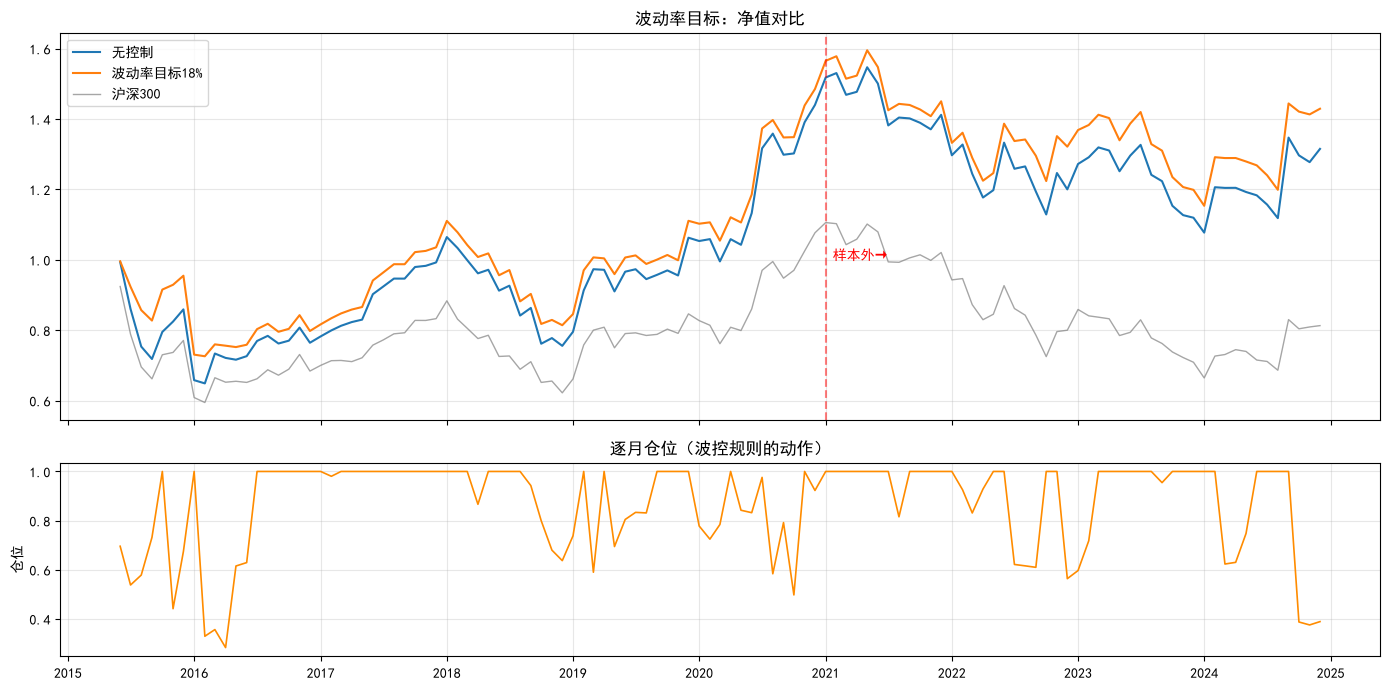

In [6]:
tv_best, lb_best = 0.18, 3   

r_adj, w = apply_vol_target(net_plain, target_vol=tv_best, lookback=lb_best)
oos_idx = r_adj.index[r_adj.index >= split]

cmp_oos = pd.DataFrame({'no_control': perf_stats(net_plain.loc[oos_idx], b_ret),
                        f'vol_target_{tv_best:.0%}/lb{lb_best}': perf_stats(r_adj.loc[oos_idx], b_ret)})
print(cmp_oos.round(3))
print(f"Out-of-sample average position size {w.loc[oos_idx].mean()*100:.0f}%, share of full-position months {(w.loc[oos_idx]>=0.999).mean()*100:.0f}%")

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                       gridspec_kw={'height_ratios':[2,1]})
oos_all = r_adj.index
ax[0].plot(oos_all, (1+net_plain.loc[oos_all]).cumprod(), label='No control', lw=1.5)
ax[0].plot(oos_all, (1+r_adj).cumprod(), label=f'Volatility target {tv_best:.0%}', lw=1.5)
ax[0].plot(oos_all, (1+b_ret.loc[oos_all]).cumprod(), label='CSI 300', lw=1, color='gray', alpha=0.7)
ax[0].axvline(split, color='red', ls='--', alpha=0.5); ax[0].text(split, 1, ' Out-of-sample ->', color='red')
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title('Volatility Targeting: NAV Comparison')
ax[1].plot(w.index, w.values, lw=1.2, color='darkorange')
ax[1].set_ylabel('Position size'); ax[1].grid(alpha=0.3); ax[1].set_title('Monthly Position Size (Volatility-Targeting Overlay Action)')
plt.tight_layout(); plt.show()